## 📥 1. Data Loading

Load tweets data from SQLite database:

1. **Connect to database**: Read all tables from `tweetsDB.sqlite`
2. **Date formatting**: Convert date columns to standardized `YYYY-MM-DD HH-MM-SS` format
   - `Timestamp`: tweet timestamp

In [11]:
import sqlite3
import pandas as pd
from datetime import datetime
from tabulate import tabulate

DB_PATH = "../data/tweetsCleanedDB.sqlite"
TABLE_NAME = "tweets"

conn = sqlite3.connect(DB_PATH)

print(f"Processing table: {TABLE_NAME}")

cols = pd.read_sql_query(f"PRAGMA table_info({TABLE_NAME});", conn)["name"].tolist()

df = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", conn)
print(f"Loaded {len(df)} rows")

if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['date'] = df['Timestamp'].dt.date
    df['time'] = df['Timestamp'].dt.time
    df['day_of_week'] = df['Timestamp'].dt.day_name()
    df['hour'] = df['Timestamp'].dt.hour
    df['year'] = df['Timestamp'].dt.year

print(f"\n{'='*50}")
print(f"Columns: {df.columns.tolist()}")
summary = pd.DataFrame([(TABLE_NAME, len(df))], columns=["table_name", "num_rows"])
print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))

# Column datatypes
print(f"\n{'='*50}")
print("Column Datatypes:")
dtype_df = pd.DataFrame({
    "column": df.dtypes.index,
    "pandas_dtype": df.dtypes.values.astype(str),
    "sqlite_dtype": pd.read_sql_query(f"PRAGMA table_info({TABLE_NAME});", conn)["type"].tolist() + ["derived"] * (len(df.columns) - len(cols))
})
print(tabulate(dtype_df, headers="keys", tablefmt="github", showindex=False))

Processing table: tweets
Loaded 9909 rows

Columns: ['tweet_id', 'username', 'text', 'retweets', 'likes', 'timestamp', 'date', 'time', 'hour', 'day_name', 'year_week', 'year_month', 'year']
| table_name   |   num_rows |
|--------------|------------|
| tweets       |       9909 |

Column Datatypes:
| column     | pandas_dtype   | sqlite_dtype   |
|------------|----------------|----------------|
| tweet_id   | object         | TEXT           |
| username   | object         | TEXT           |
| text       | object         | TEXT           |
| retweets   | int64          | INTEGER        |
| likes      | int64          | INTEGER        |
| timestamp  | object         | TIMESTAMP      |
| date       | object         | DATE           |
| time       | object         | TEXT           |
| hour       | int64          | INTEGER        |
| day_name   | object         | TEXT           |
| year_week  | object         | TEXT           |
| year_month | object         | TEXT           |
| year       | 

## 📊 1. Engagement Analysis Over Time
- Temporal analysis: Total engagement = likes + retweets

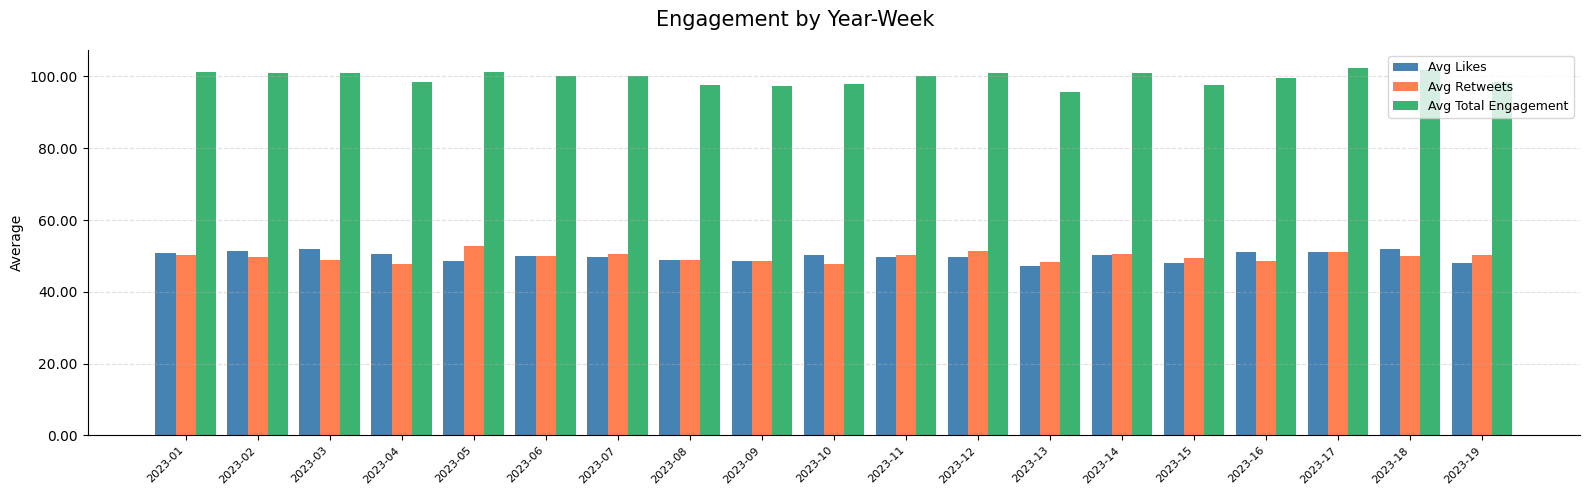

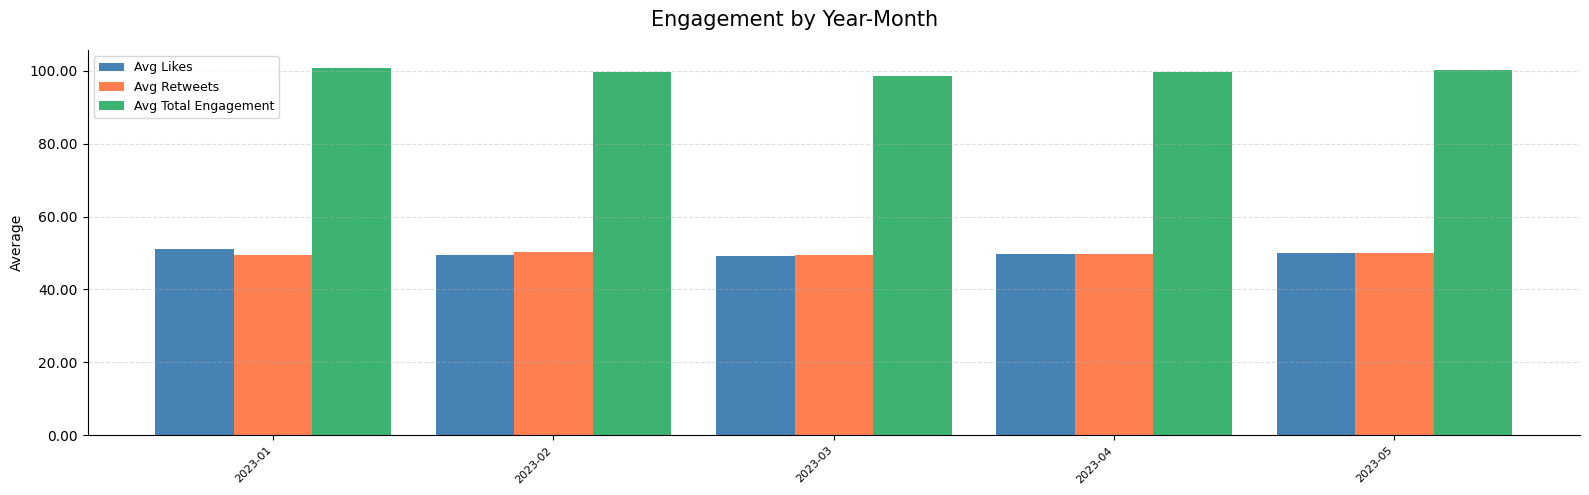

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Engagement Aggregations ──────────────────────────────────────────────────

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

engagement_cols = ['likes', 'retweets']

def agg_engagement(df, group_col):
    agg = (df.groupby(group_col)[engagement_cols]
             .mean()
             .round(2))
    agg.columns = ['likes_mean', 'retweets_mean']
    agg['total_mean'] = agg['likes_mean'] + agg['retweets_mean']
    return agg.reset_index()

# By Year-Week
by_week  = agg_engagement(df, 'year_week')

# By Year-Month
by_month = agg_engagement(df, 'year_month')

# ── Plot Helper ───────────────────────────────────────────────────────────────

def plot_engagement(agg_df, x_col, title, rotate=0, max_ticks=20):
    fig, ax = plt.subplots(figsize=(16, 5))
    fig.suptitle(title, fontsize=15)

    x_labels = agg_df[x_col].astype(str).tolist()
    x_pos    = list(range(len(x_labels)))
    width    = 0.28

    ax.bar([x - width for x in x_pos], agg_df['likes_mean'],    width=width, label='Avg Likes',            color='steelblue')
    ax.bar([x         for x in x_pos], agg_df['retweets_mean'], width=width, label='Avg Retweets',         color='coral')
    ax.bar([x + width for x in x_pos], agg_df['total_mean'],    width=width, label='Avg Total Engagement', color='mediumseagreen')

    step        = max(1, len(x_labels) // max_ticks)
    tick_pos    = list(range(0, len(x_labels), step))
    tick_labels = [x_labels[i] for i in tick_pos]

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=rotate, ha='right' if rotate else 'center', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.2f}'))
    ax.set_ylabel("Average", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# ── Plots ─────────────────────────────────────────────────────────────────────

plot_engagement(by_week,  'year_week',  "Engagement by Year-Week",  rotate=45)
plot_engagement(by_month, 'year_month', "Engagement by Year-Month", rotate=45)

### Comments
- There is virtually no noticeable growth in retweets and likes over time.
- The number of retweets and likes remains relatively constant, showing little to no upward trend.
- This stability may suggest that the platform has reached a mature stage, where engagement levels have stabilized rather than continuing to grow.

## 🔁 2. Engagement Per Tweet Over Time
- Total engagement = likes + retweets
- Tweets = count(id)
- Engagements/Tweet = Total engagement/tweets

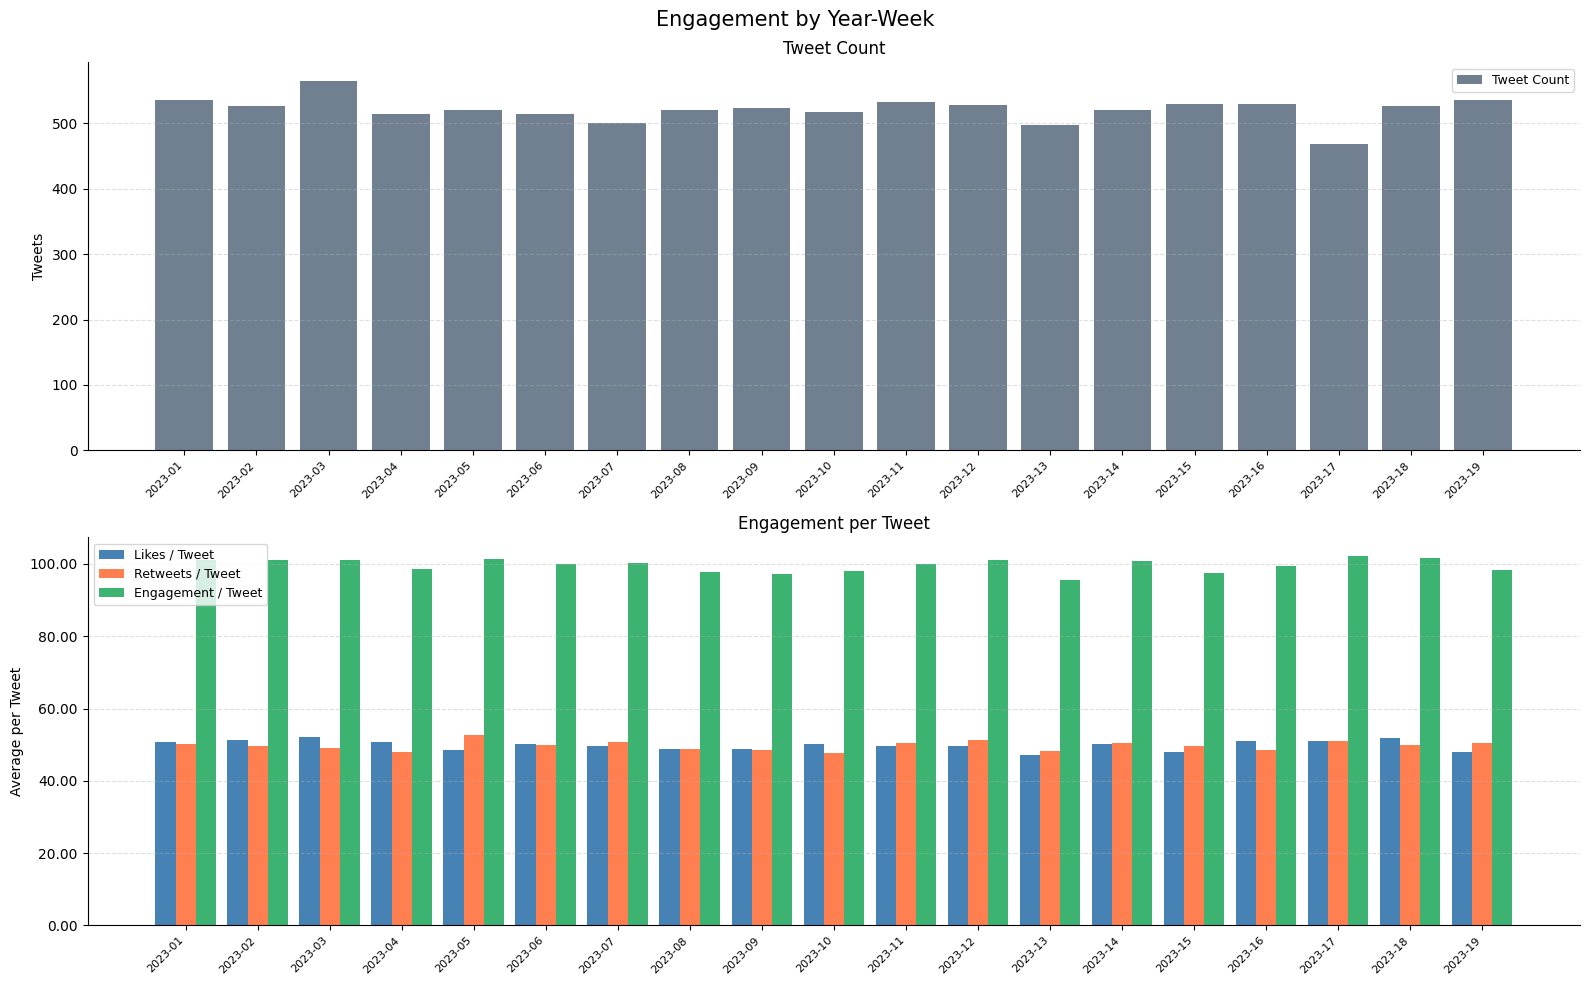

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Engagement Aggregations ──────────────────────────────────────────────────

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

engagement_cols = ['likes', 'retweets']

def agg_engagement(df, group_col):
    agg = df.groupby(group_col)[engagement_cols].sum().round(2)
    agg.columns = ['likes_total', 'retweets_total']
    agg['tweet_count']          = df.groupby(group_col).size()
    agg['likes_per_tweet']      = (agg['likes_total']    / agg['tweet_count']).round(2)
    agg['retweets_per_tweet']   = (agg['retweets_total'] / agg['tweet_count']).round(2)
    agg['engagement_per_tweet'] = agg['likes_per_tweet'] + agg['retweets_per_tweet']
    return agg.reset_index()

# By Year-Week
by_week = agg_engagement(df, 'year_week')

# ── Plot ──────────────────────────────────────────────────────────────────────

def plot_engagement(agg_df, x_col, title, rotate=0, max_ticks=20):
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle(title, fontsize=15)

    x_labels = agg_df[x_col].astype(str).tolist()
    x_pos    = list(range(len(x_labels)))
    width    = 0.28

    step        = max(1, len(x_labels) // max_ticks)
    tick_pos    = list(range(0, len(x_labels), step))
    tick_labels = [x_labels[i] for i in tick_pos]

    # ── Top: Tweet Count ──────────────────────────────────────────────────────
    ax = axes[0]
    ax.bar(x_pos, agg_df['tweet_count'], color='slategray', label='Tweet Count')
    ax.set_title("Tweet Count", fontsize=12)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=rotate, ha='right' if rotate else 'center', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_ylabel("Tweets", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Bottom: Per-Tweet Metrics ─────────────────────────────────────────────
    ax = axes[1]
    ax.bar([x - width for x in x_pos], agg_df['likes_per_tweet'],      width=width, label='Likes / Tweet',      color='steelblue')
    ax.bar([x         for x in x_pos], agg_df['retweets_per_tweet'],   width=width, label='Retweets / Tweet',   color='coral')
    ax.bar([x + width for x in x_pos], agg_df['engagement_per_tweet'], width=width, label='Engagement / Tweet', color='mediumseagreen')
    ax.set_title("Engagement per Tweet", fontsize=12)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=rotate, ha='right' if rotate else 'center', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.2f}'))
    ax.set_ylabel("Average per Tweet", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# ── Plot ──────────────────────────────────────────────────────────────────────

plot_engagement(by_week, 'year_week', "Engagement by Year-Week", rotate=45)

### Comments
- Tweet count remains relatively stable over time.
- When combined with the observation that overall engagement is also stable, this suggests that engagement per tweet is likely stable over time as well. The above graph verifies this deduction. 

## 👤 3. Engagement and Tweet Count by Username
- Total Engagement ❤️🔁 = Likes + Retweets
- Tweet Count 📝 = Number of tweets per user

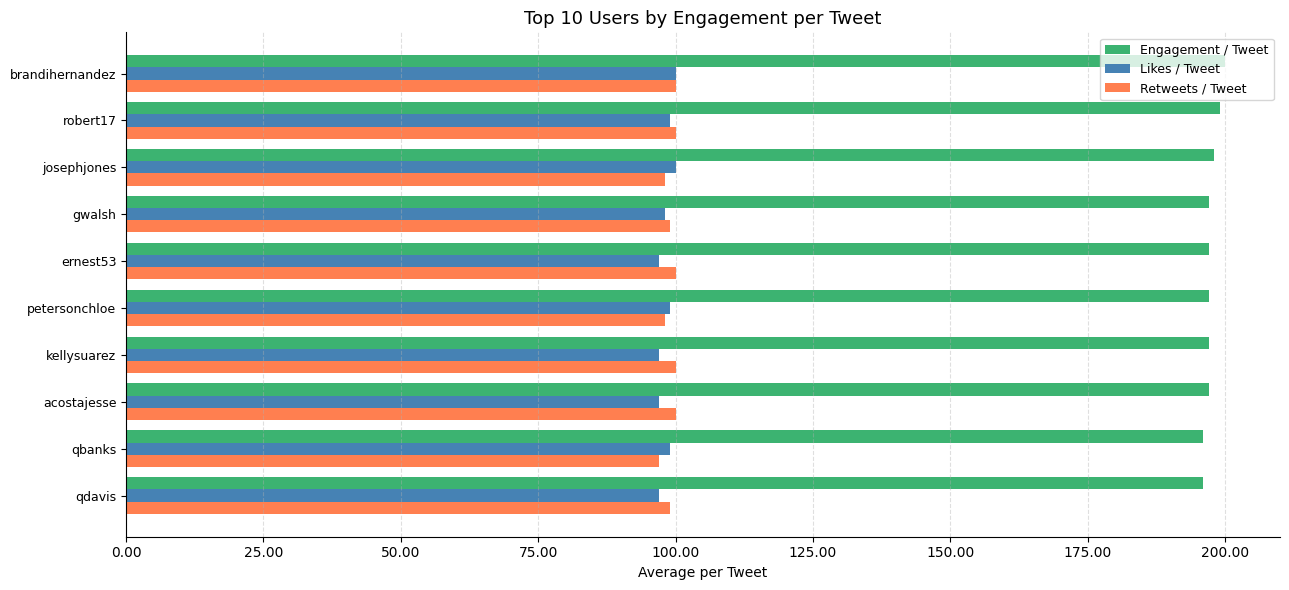

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Per-Username Aggregations ─────────────────────────────────────────────────

engagement_cols = ['likes', 'retweets']

def agg_by_user(df):
    agg = df.groupby('username')[engagement_cols].sum().round(2)
    agg.columns = ['likes_total', 'retweets_total']
    agg['tweet_count']          = df.groupby('username').size()
    agg['likes_per_tweet']      = (agg['likes_total']    / agg['tweet_count']).round(2)
    agg['retweets_per_tweet']   = (agg['retweets_total'] / agg['tweet_count']).round(2)
    agg['engagement_per_tweet'] = agg['likes_per_tweet'] + agg['retweets_per_tweet']
    return agg.reset_index()

by_user  = agg_by_user(df)
top10    = by_user.nlargest(10, 'engagement_per_tweet').sort_values('engagement_per_tweet')

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 6))

usernames = top10['username'].astype(str).tolist()
y_pos     = list(range(len(usernames)))
height    = 0.26

ax.barh([y + height for y in y_pos], top10['engagement_per_tweet'], height=height, label='Engagement / Tweet', color='mediumseagreen')
ax.barh([y          for y in y_pos], top10['likes_per_tweet'],      height=height, label='Likes / Tweet',      color='steelblue')
ax.barh([y - height for y in y_pos], top10['retweets_per_tweet'],   height=height, label='Retweets / Tweet',   color='coral')

ax.set_yticks(y_pos)
ax.set_yticklabels(usernames, fontsize=9)
ax.set_title("Top 10 Users by Engagement per Tweet", fontsize=13)
ax.set_xlabel("Average per Tweet", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.2f}'))
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)

### Comments
- The users shown above are the most engaging and influential users, generating the highest levels of interaction on the platform.

## 📈 4. Check Correlation between Likes and Retweets
- Corr. Coeff(likes,retweets)

Pearson Correlation (likes vs retweets): 0.0110


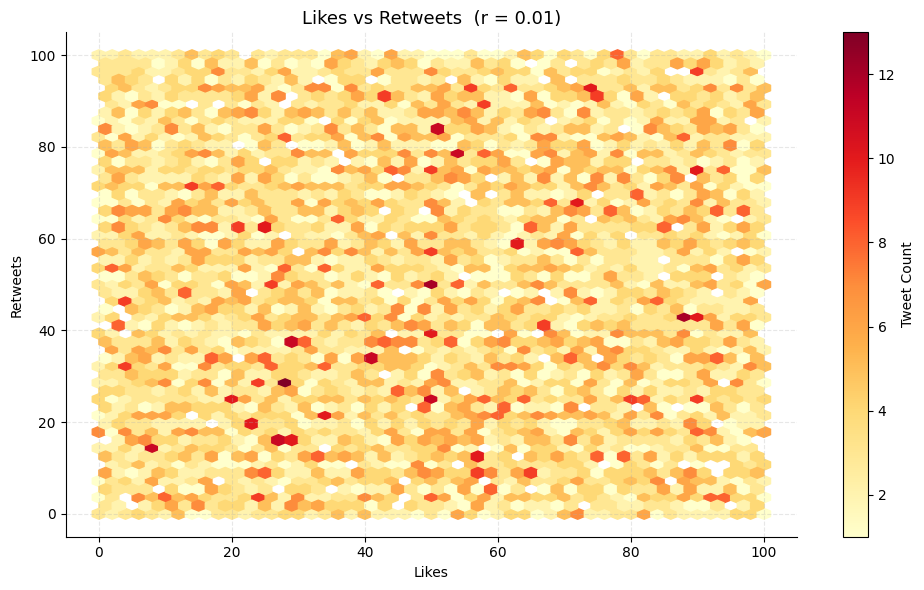

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# ── Correlation ───────────────────────────────────────────────────────────────

corr = df[['likes', 'retweets']].corr().loc['likes', 'retweets']
print(f"Pearson Correlation (likes vs retweets): {corr:.4f}")

# ── Hex Density Plot ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(df['likes'], df['retweets'], gridsize=50, cmap='YlOrRd', mincnt=1)
fig.colorbar(hb, ax=ax, label='Tweet Count')

ax.set_title(f"Likes vs Retweets  (r = {corr:.2f})", fontsize=13)
ax.set_xlabel("Likes", fontsize=10)
ax.set_ylabel("Retweets", fontsize=10)
ax.grid(linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)

### Comments
- likes and retweets are uncorrelated!

## 📈 5. Check Correlation between Length of Tweet and Likes and Retweets
- Corr. Coeff(tweet-length,likes)
- Corr. Coeff(tweet-length,retweets)

Pearson Correlation (tweet length vs likes):    -0.0017
Pearson Correlation (tweet length vs retweets): 0.0101


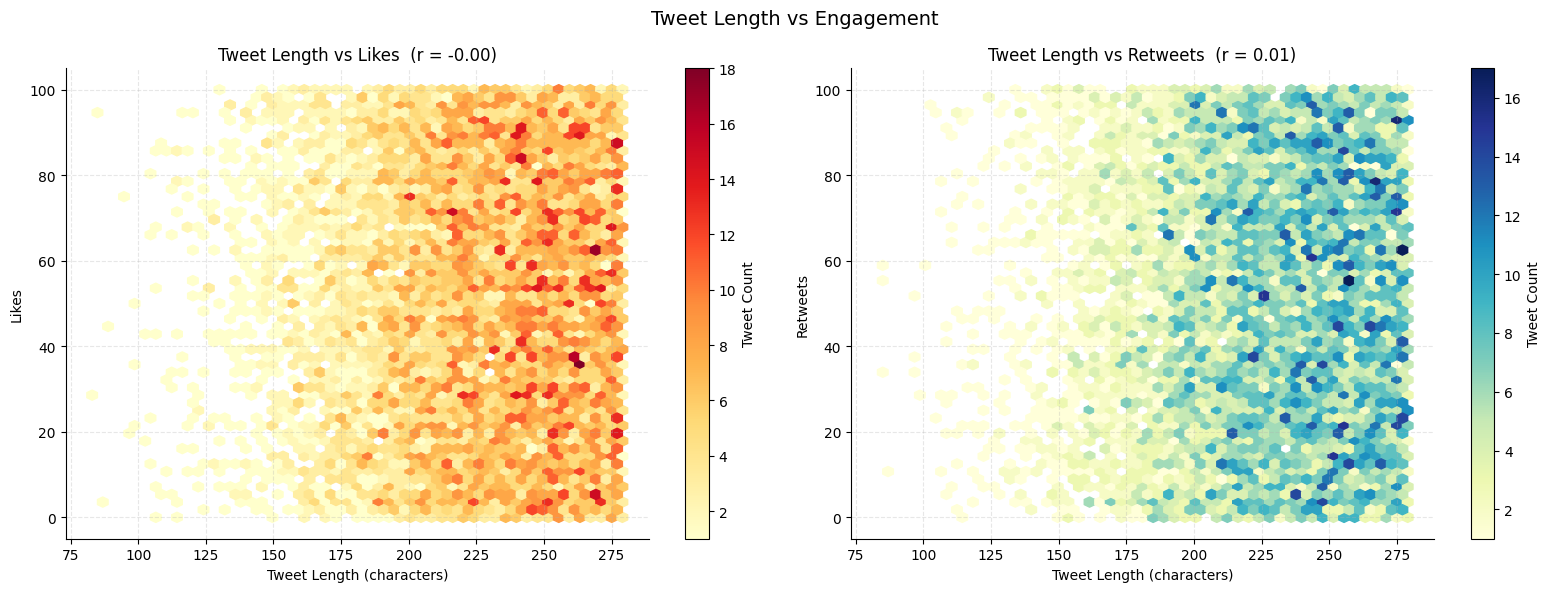

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ── Tweet Length ──────────────────────────────────────────────────────────────

df['tweet_length'] = df['text'].astype(str).str.len()

# ── Correlations ─────────────────────────────────────────────────────────────

corr_likes    = df[['tweet_length', 'likes']].corr().loc['tweet_length', 'likes']
corr_retweets = df[['tweet_length', 'retweets']].corr().loc['tweet_length', 'retweets']

print(f"Pearson Correlation (tweet length vs likes):    {corr_likes:.4f}")
print(f"Pearson Correlation (tweet length vs retweets): {corr_retweets:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Tweet Length vs Engagement", fontsize=14)

for ax, metric, corr, color, label in zip(
    axes,
    ['likes',                       'retweets'],
    [corr_likes,                    corr_retweets],
    ['YlOrRd',                      'YlGnBu'],
    ['Tweet Length vs Likes',       'Tweet Length vs Retweets'],
):
    hb = ax.hexbin(df['tweet_length'], df[metric], gridsize=50, cmap=color, mincnt=1)
    fig.colorbar(hb, ax=ax, label='Tweet Count')
    ax.set_title(f"{label}  (r = {corr:.2f})", fontsize=12)
    ax.set_xlabel("Tweet Length (characters)", fontsize=10)
    ax.set_ylabel(metric.title(), fontsize=10)
    ax.grid(linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)

### Comments
- Tweet length shows no correlation with likes or retweets, indicating that the length of a tweet does not impact engagement.
- This suggests that the content of the tweet, rather than its length, is likely the key driver of engagement.